# Experiment 2: Data Wrangling using Python
### Subject: DSBDA (Data Science & Big Data Analytics)

This notebook demonstrates basic **Data Wrangling operations** using Python and Pandas on an open‑source dataset.

### Problem Statement
**Data Wrangling-II**, Create an “Academic performance” dataset of students and perform the following operations using Python. 1. Scan all variables for missing values and inconsistencies. If there are missing values and/or inconsistencies, use any of the suitable techniques to deal with them. 2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with them. 3. Apply data transformations on at least one of the variables. The purpose of this transformation should be one of the following reasons: to change the scale for better understanding of the variable, to convert a non-linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal distribution. Reason and document your approach properly.

### Dataset Used
**Student Performance in exam** (Academic performance Data)

Source: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams



In [1]:
#1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset & Describe

In [2]:
#Load dataset
df=pd.read_csv("StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [14]:
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,0.536507,0.566211,0.569570
std,0.204417,0.204274,0.203283
min,0.000000,0.000000,0.000000
25%,0.410959,0.422535,0.430017
50%,0.534247,0.577465,0.581788
75%,0.684932,0.704225,0.716695
max,1.000000,1.000000,1.000000


## Handling Missing Values & Inconsistencies

In [6]:
#Check missing values
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [19]:
#df.fillna(df.mean(numeric_only=True), inplace=True)
#df.fillna(df.mode(numeric_only=True), inplace=True)

In [7]:
#Check inconsistancy
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Detecting and Handling Outliers

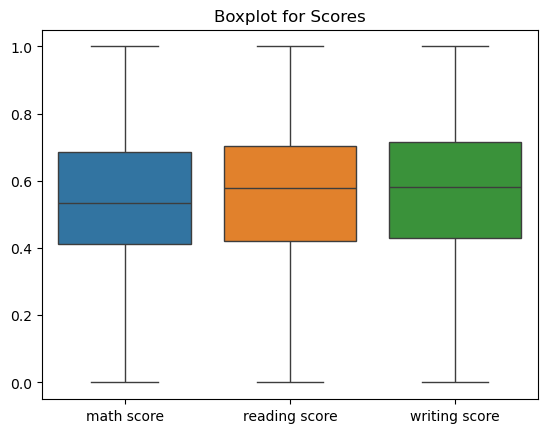

In [16]:
# Boxplot for outliers
plt.figure()
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.title("Boxplot for Scores")
plt.show()

In [17]:
# Using IQR method
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in df.select_dtypes(include=np.number):
    df = remove_outliers(df, col)

df.shape

(1000, 8)

##  Data Transformation

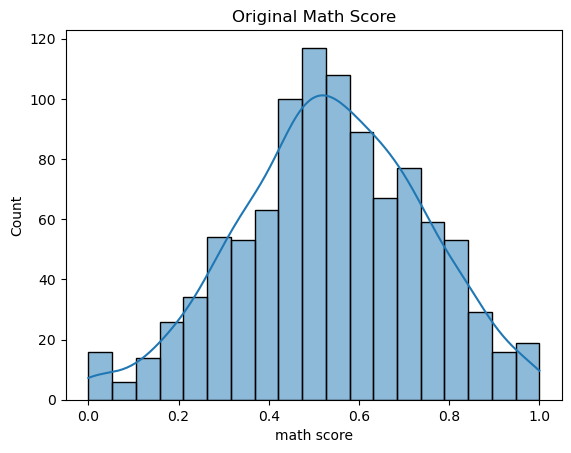

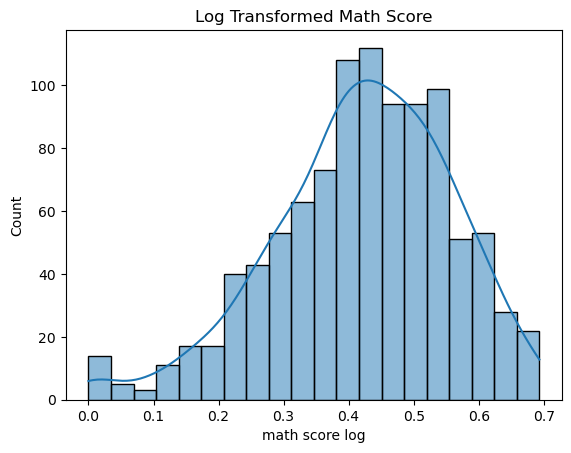

In [18]:
# Log Transformation to Reduce Skewness
# Apply log transformation
df['math score log'] = np.log1p(df['math score'])

# Compare distributions
sns.histplot(df['math score'], kde=True)
plt.title("Original Math Score")
plt.show()

sns.histplot(df['math score log'], kde=True)
plt.title("Log Transformed Math Score")
plt.show()

## Conclusion
- Missing values handled using mean/mode
- Outliers removed using IQR method
- Log transformation applied to reduce skewness and normalize distribution